In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [3]:
df=pd.read_excel("premiums_rest.xlsx")
df.head(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164


In [4]:
df['Genetical_Risk'] = 0

In [5]:
df.shape

(29904, 14)

In [6]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [7]:
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0


In [8]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handle NA value 

In [9]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Duplicate handling

In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.379910,23.364184,20892.303821,0.0
std,13.412657,1.431201,24.740339,6936.813440,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


In [12]:
df[df['number_of_dependants'] < 0].shape

(50, 14)

In [13]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-1, -3])

In [14]:
df['number_of_dependants'] = abs(df['number_of_dependants'])

In [15]:
df[df['number_of_dependants'] < 0].shape

(0, 14)

In [16]:
df['number_of_dependants'].describe()

count    29886.000000
mean         2.385933
std          1.421137
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

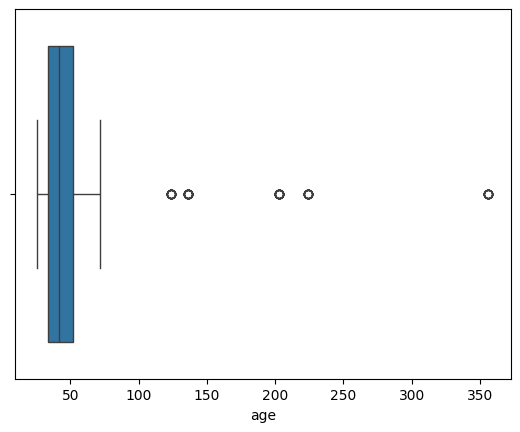

In [17]:
sns.boxplot(x=df['age'])
plt.show()

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

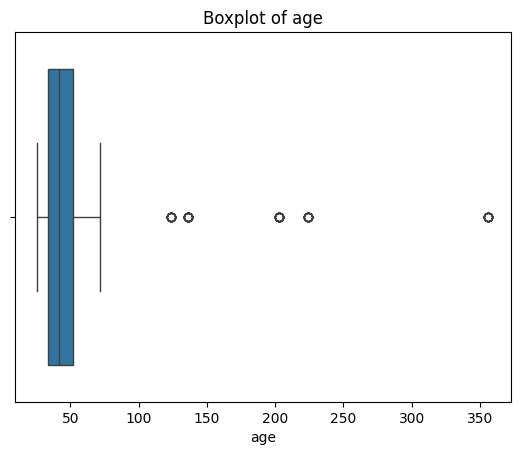

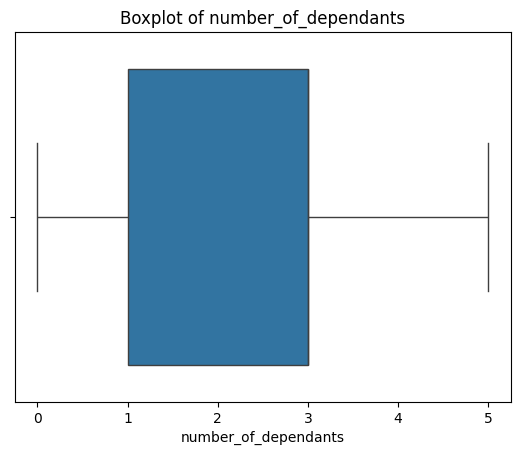

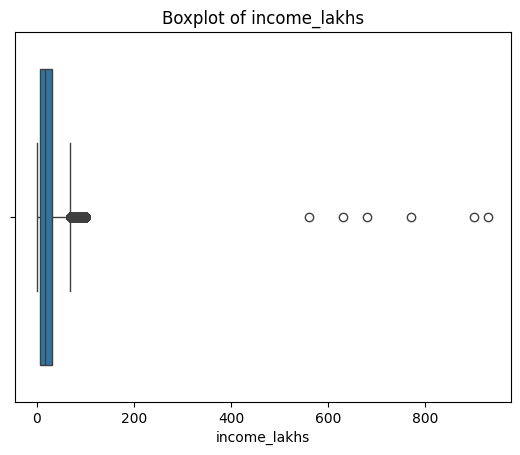

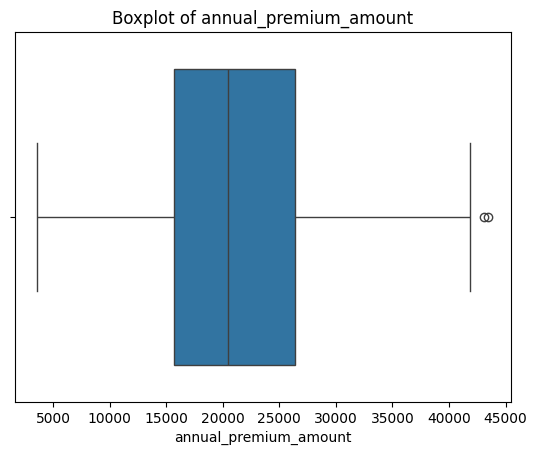

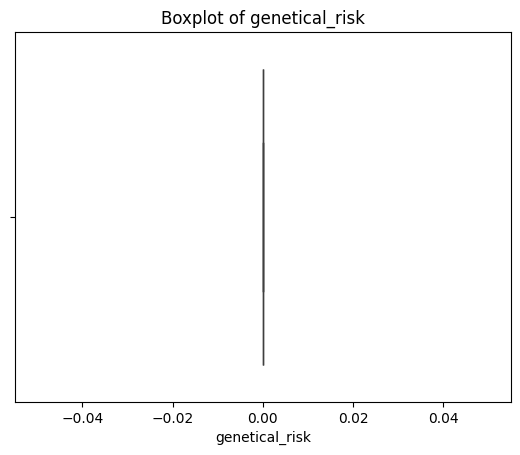

In [19]:
for col in numeric_columns:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [20]:
df[df.age>100]['age'].unique()

array([224, 124, 136, 203, 356])

In [21]:
df1 = df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29828.000000,29828.000000,29828.000000,29828.000000,29828.0
mean,43.095380,2.387790,23.371530,20901.900563,0.0
std,11.041991,1.420641,24.751262,6928.457636,0.0
min,26.000000,0.000000,1.000000,6538.000000,0.0
25%,34.000000,1.000000,7.000000,15706.000000,0.0
50%,42.000000,3.000000,17.000000,20496.000000,0.0
75%,52.000000,3.000000,32.000000,26361.000000,0.0
max,72.000000,5.000000,930.000000,43471.000000,0.0


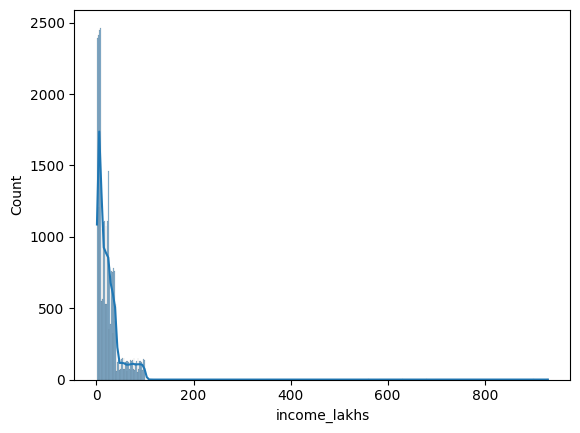

In [22]:
sns.histplot(df1.income_lakhs, kde=True)
plt.show()

In [23]:
df1.income_lakhs.quantile([0.25, 0.75])


0.25     7.0
0.75    32.0
Name: income_lakhs, dtype: float64

In [24]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [25]:
get_iqr_bounds(df1.income_lakhs)

(-30.5, 69.5)

In [26]:
quantile_threshold = df1.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [27]:
df1[df1.income_lakhs > quantile_threshold].shape

(6, 14)

In [28]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.0
mean,43.094896,2.387734,23.226343,20900.689223,0.0
std,11.042430,1.420644,22.455408,6928.192115,0.0
min,26.000000,0.000000,1.000000,6538.000000,0.0
25%,34.000000,1.000000,7.000000,15705.250000,0.0
50%,42.000000,3.000000,17.000000,20495.500000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,72.000000,5.000000,100.000000,43471.000000,0.0


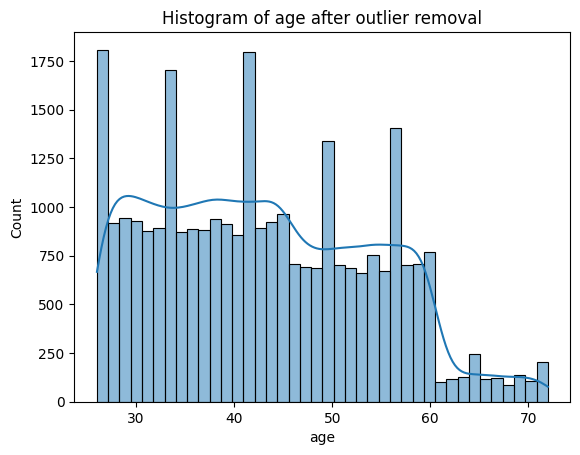

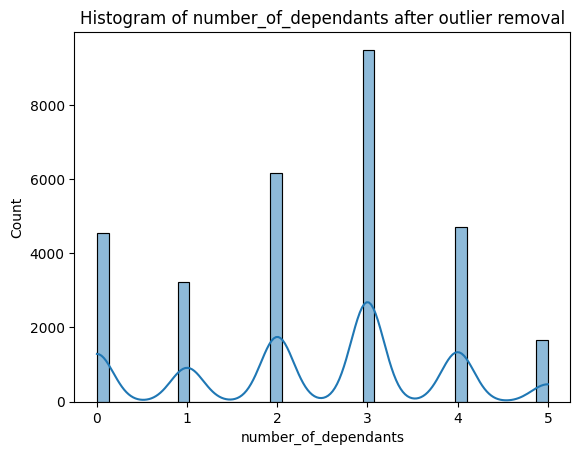

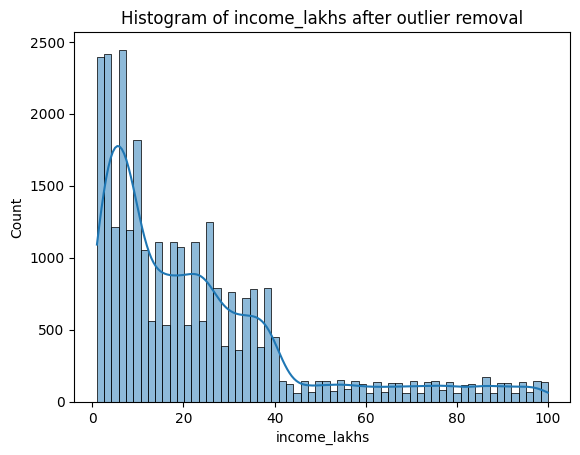

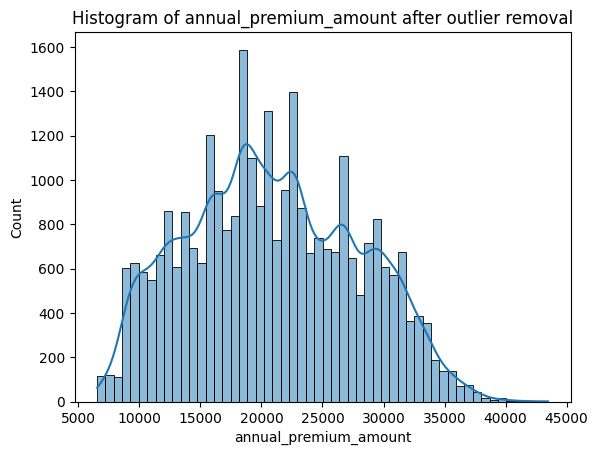

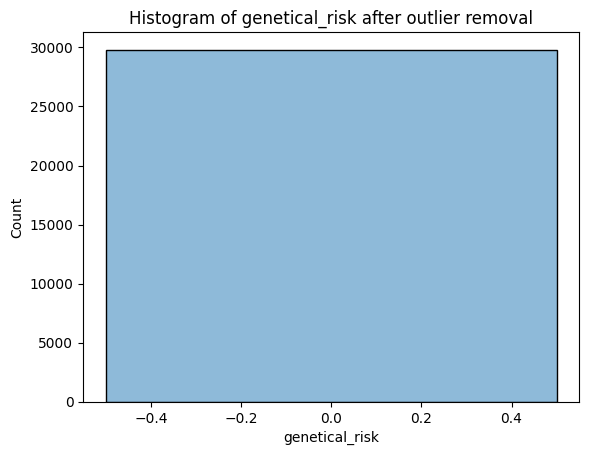

In [29]:

for col in numeric_columns:
    sns.histplot(df2[col], kde=True)
    plt.title(f'Histogram of {col} after outlier removal')
    plt.show()

plt.show()

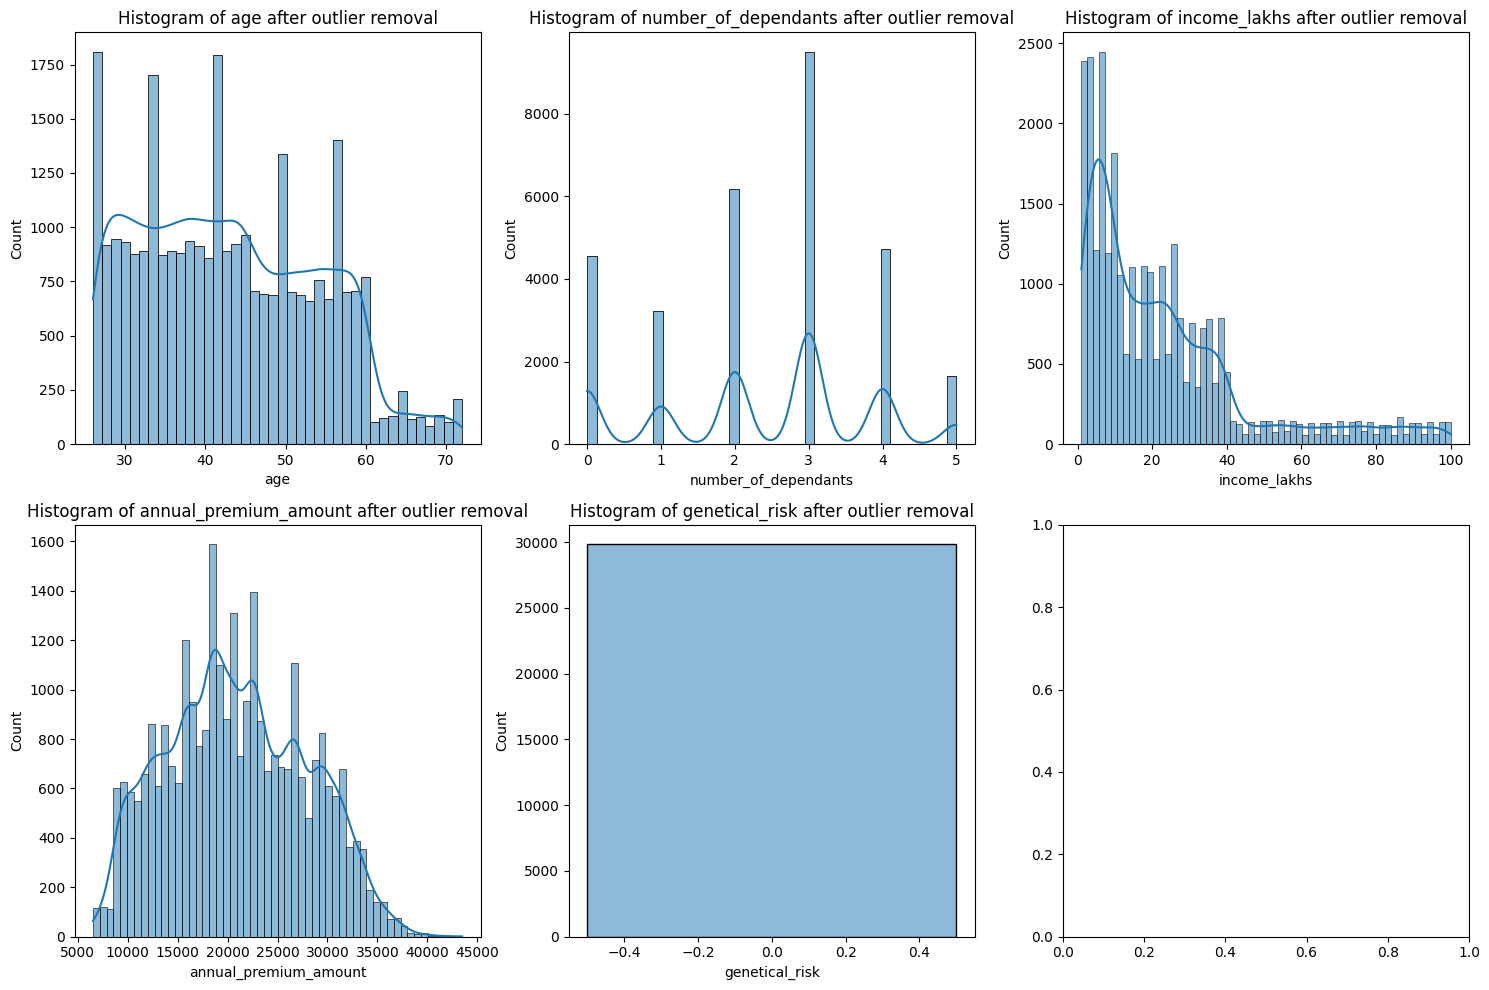

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.histplot(df2[col], kde=True, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'Histogram of {col} after outlier removal')
plt.tight_layout()
plt.show()

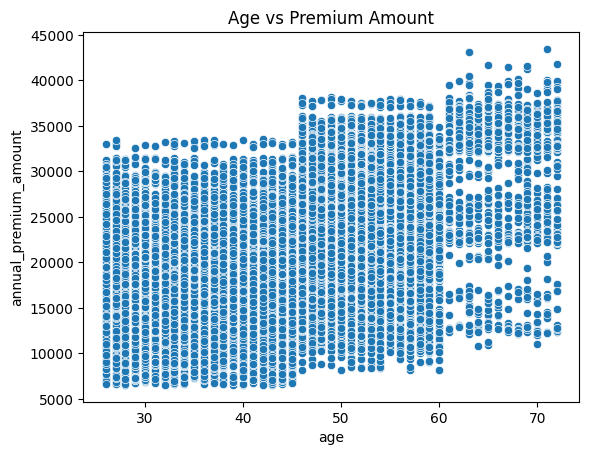

In [31]:
sns.scatterplot(x=df2['age'], y=df2['annual_premium_amount'])
plt.title('Age vs Premium Amount')
plt.show()

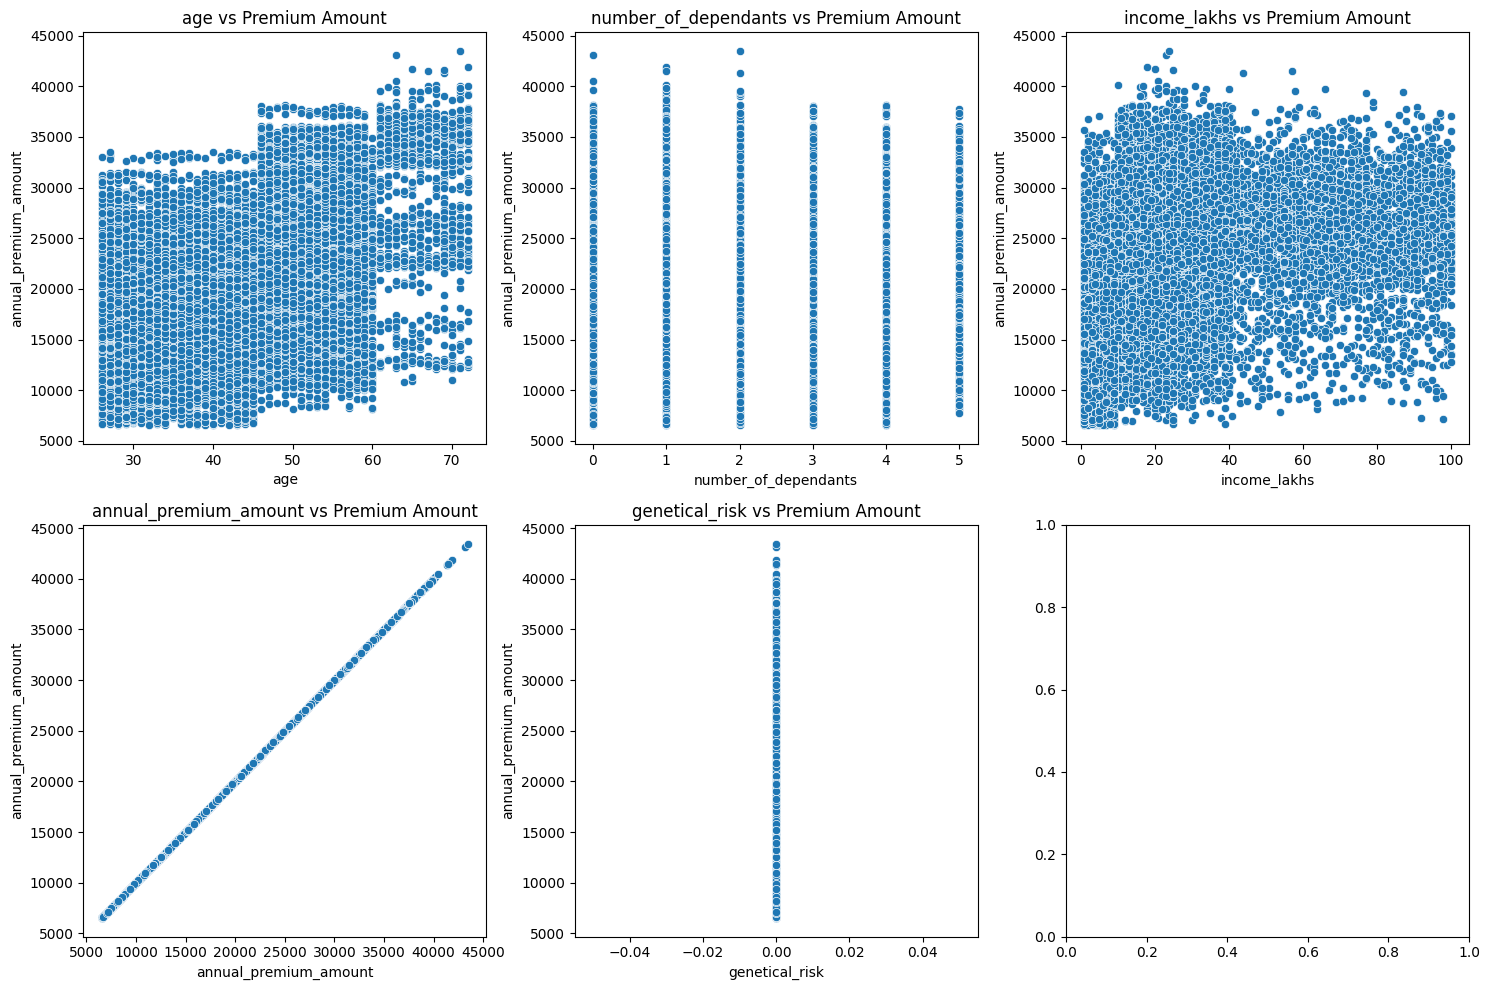

In [32]:
# two layouts for scatter plots
numeric_columns = df2.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    sns.scatterplot(x=df2[col], y=df2['annual_premium_amount'], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f'{col} vs Premium Amount')
plt.tight_layout()
plt.show()


In [33]:
categorical_columns = df2.select_dtypes(include='object').columns
for col in categorical_columns:
    print(f'Value counts for {col}:')
    print(df2[col].unique())

Value counts for gender:
['Male' 'Female']
Value counts for region:
['Northwest' 'Southeast' 'Northeast' 'Southwest']
Value counts for marital_status:
['Unmarried' 'Married']
Value counts for bmi_category:
['Normal' 'Obesity' 'Overweight' 'Underweight']
Value counts for smoking_status:
['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
Value counts for employment_status:
['Salaried' 'Self-Employed' 'Freelancer']
Value counts for income_level:
['<10L' '10L - 25L' '> 40L' '25L - 40L']
Value counts for medical_history:
['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
Value counts for insurance_plan:
['Bronze' 'Silver' 'Gold']


In [34]:
df2['smoking_status'].replace(
    {
        'Smoking=0':'No Smoking',
         'Does Not Smoke':'No Smoking',
         'Not Smoking':'No Smoking',
    },
    inplace=True
)
df2['smoking_status'].unique()

C:\Users\hapatil\AppData\Local\Temp\ipykernel_22672\2684999231.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['smoking_status'].replace(


array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [35]:
ptc_count =df2['gender'].value_counts(normalize=True)
ptc_count

gender
Male      0.549125
Female    0.450875
Name: proportion, dtype: float64

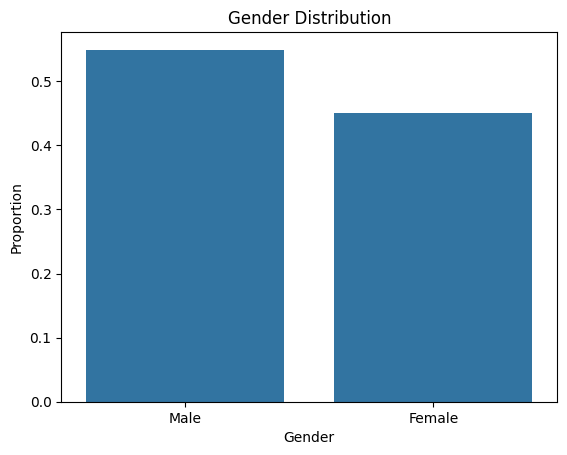

In [36]:
sns.barplot(x=ptc_count.index, y=ptc_count.values)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Proportion')    
plt.show()

In [37]:
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

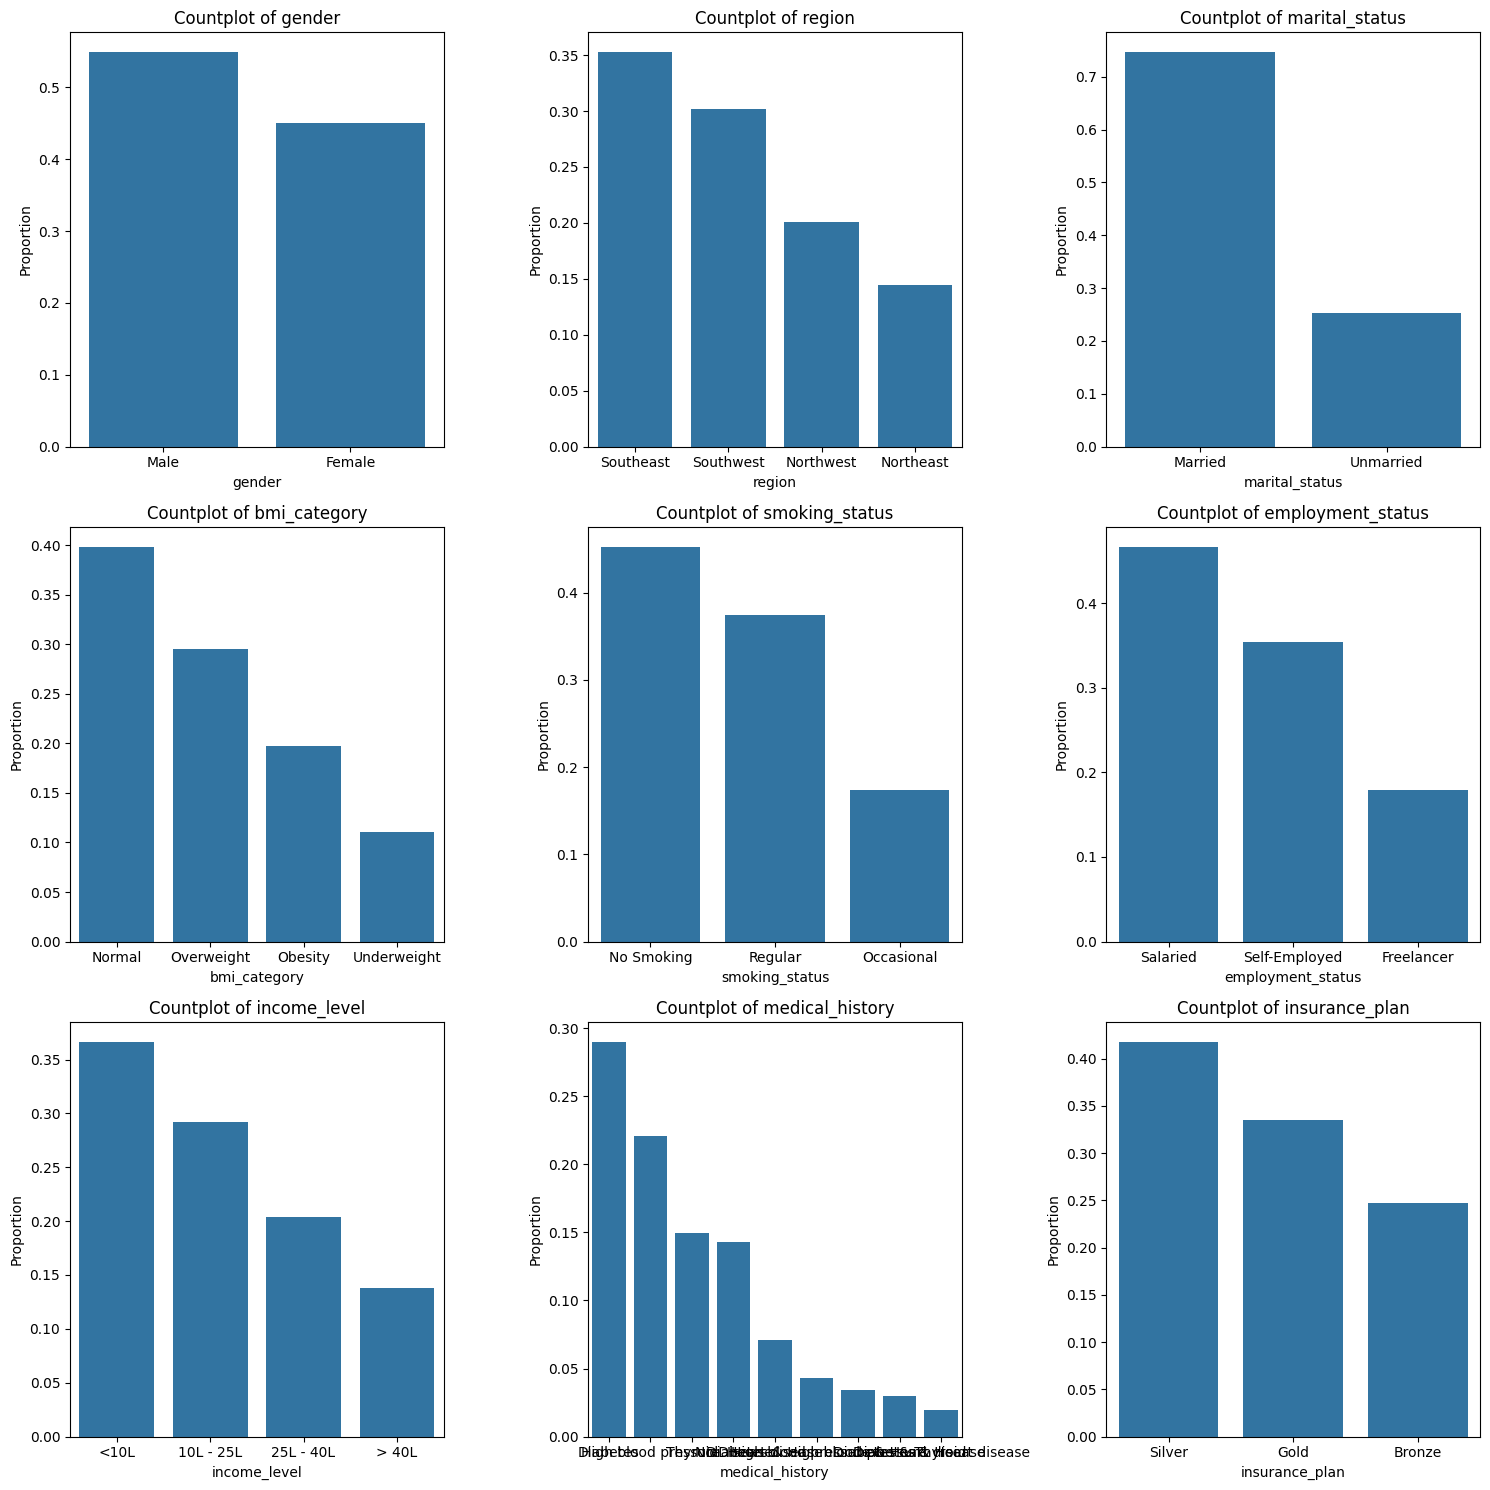

In [38]:
import math

n_plots = len(categorical_columns)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_columns):
    counts = df2[col].value_counts(normalize=True)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')

# Hide any unused subplot axes
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

insurance_plan  Bronze  Gold  Silver
income_range                        
<10L              6054   527    4341
10L-25L            742  3338    4106
25L-40L            339  2685    3188
>40L               233  3449     820


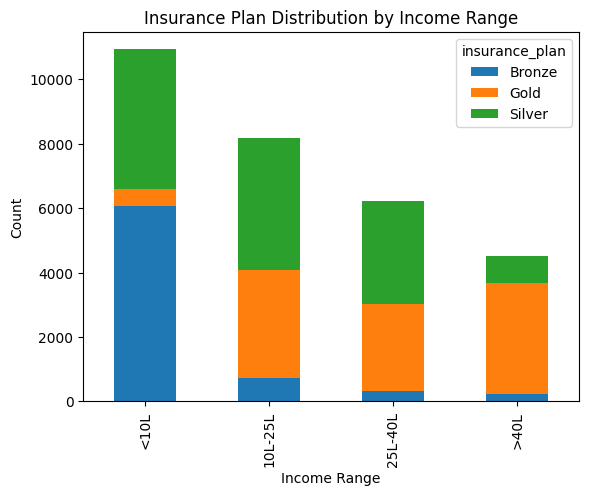

In [39]:
# Create income ranges in lakhs
income_bins = [float('-inf'), 10, 25, 40, float('inf')]
income_labels = ['<10L', '10L-25L', '25L-40L', '>40L']

df2['income_range'] = pd.cut(
    df2['income_lakhs'],
    bins=income_bins,
    labels=income_labels,
    right=False
 )

crosstab = pd.crosstab(df2['income_range'], df2['insurance_plan'])
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Insurance Plan Distribution by Income Range')
plt.xlabel('Income Range')
plt.ylabel('Count')
plt.show()

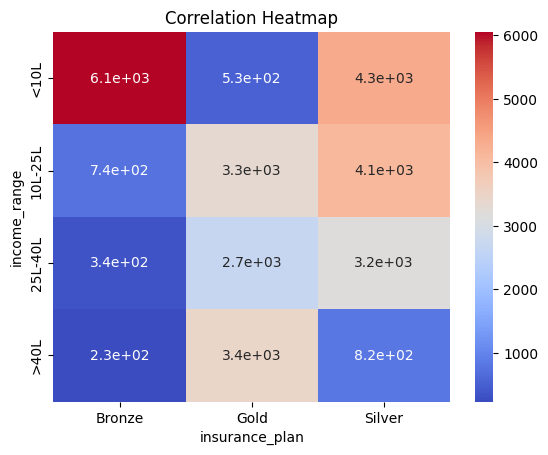

In [40]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')    
plt.show()

In [41]:
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,income_range
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,<10L
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,<10L
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,10L-25L
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,>40L
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,10L-25L


In [42]:
df2.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [43]:
risk_scores = {
    "diabetes": 6, 
    "high blood pressure": 6, 
    "no disease": 0,
    "thyroid": 5, 
    "heart disease": 8,
    "none": 0       
}

In [44]:
df2[["disease1","disease2"]] = df2.medical_history.str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,income_range,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,<10L,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,<10L,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,10L-25L,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,>40L,no disease,None
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,10L-25L,diabetes,None


In [45]:
df2['disease1'].fillna('none', inplace=True)
df2['disease2'].fillna('none', inplace=True)

df2['total_risk_score'] = 0

for disease_col in ['disease1', 'disease2']:
    df2['total_risk_score'] += df2[disease_col].map(risk_scores)

max_risk_score = df2['total_risk_score'].max()
min_risk_score = df2['total_risk_score'].min()
df2['normalized_risk_score'] = (df2['total_risk_score'] - min_risk_score) / (max_risk_score - min_risk_score)
df2.head(5)

C:\Users\hapatil\AppData\Local\Temp\ipykernel_22672\3450494256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['disease1'].fillna('none', inplace=True)
C:\Users\hapatil\AppData\Local\Temp\ipykernel_22672\3450494256.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0,<10L,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0,<10L,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0,10L-25L,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,>40L,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0,10L-25L,diabetes,none,6,0.428571


In [46]:
df2.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [47]:
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df2.head()
df2['insurance_plan'].unique()

array([1, 2, 3])

In [48]:
df2['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [49]:
df2['income_level'] = df2['income_level'].map({'<10L': 1, '10L - 25L': 2, '25L - 40L': 3, '> 40L': 4})
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,income_range,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,0,<10L,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,0,<10L,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,2,20,High blood pressure,2,18164,0,10L-25L,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,4,77,No Disease,3,20303,0,>40L,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,2,14,Diabetes,1,15610,0,10L-25L,diabetes,none,6,0.428571


In [50]:
nominal_cols = ['gender', 'region','marital_status','bmi_category','smoking_status', 'employment_status']
df3 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True, dtype=int)

In [51]:
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,income_range,disease1,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,0,<10L,diabetes,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,0,<10L,diabetes,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,0,10L-25L,high blood pressure,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,0,>40L,no disease,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,0,10L-25L,diabetes,...,0,0,0,1,0,0,1,0,0,1


In [52]:
df4 = df3.drop(columns=['disease1', 'disease2', 'total_risk_score', 'medical_history', 'income_range'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


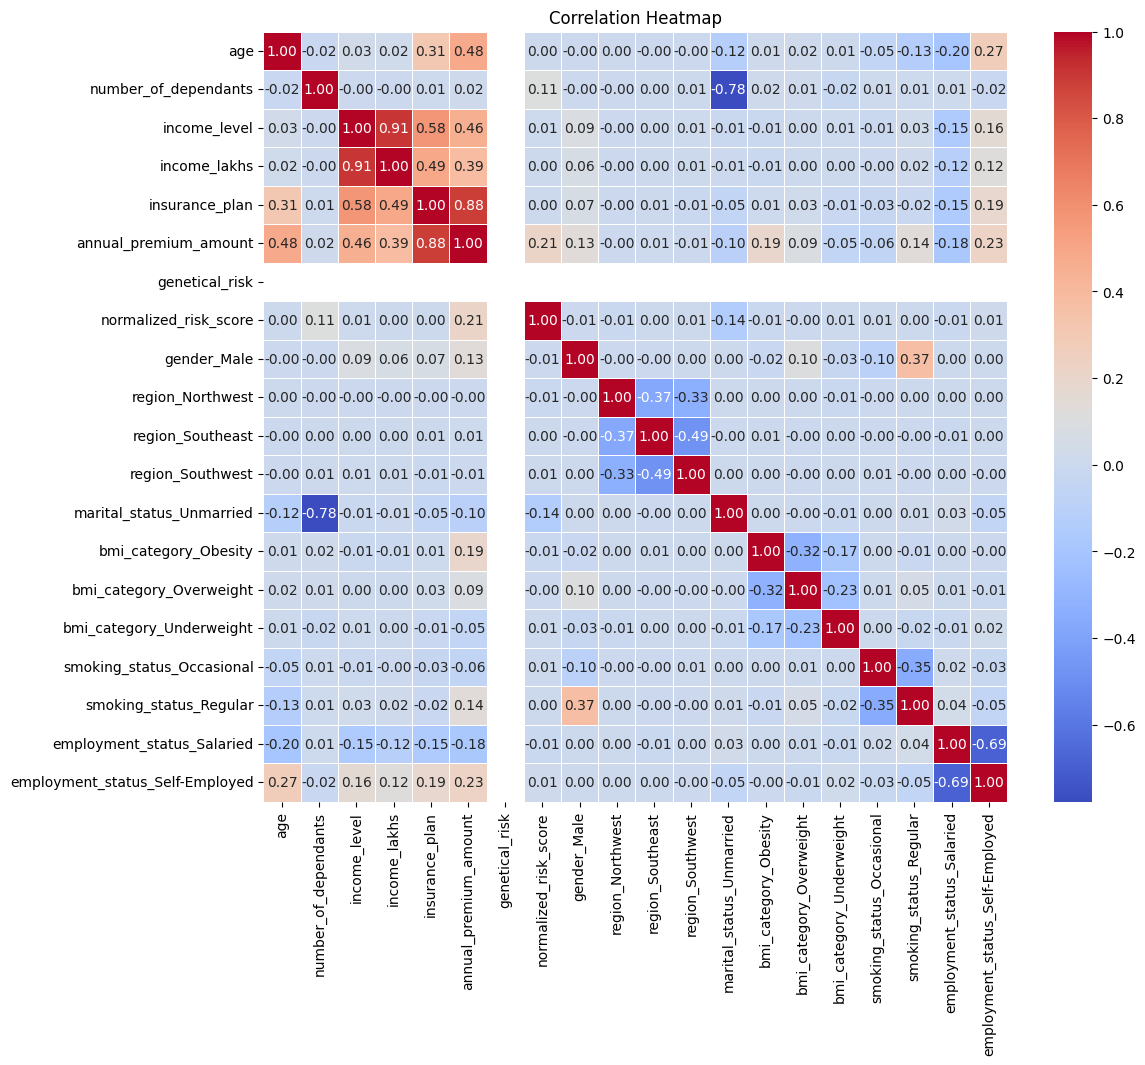

In [53]:
cm = df4.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [54]:
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


In [55]:
y = df4['annual_premium_amount']
X = df4.drop(columns=['annual_premium_amount'], axis='columns')

from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan', 'genetical_risk' ]
scaler = MinMaxScaler()
X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])
X.head()



,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,0.0,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,0.0,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,0.5,0.0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,1.0,0.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,0.0,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


In [56]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.0,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000
mean,0.371628,0.477547,0.371225,0.224509,0.544112,0.0,0.426373,0.549125,0.200691,0.352693,0.301992,0.253336,0.196835,0.295051,0.110087,0.173228,0.374656,0.466132,0.354269
std,0.240053,0.284129,0.351111,0.226822,0.379009,0.0,0.240084,0.497589,0.400524,0.477816,0.459129,0.434929,0.397613,0.456073,0.313003,0.378450,0.484042,0.498860,0.478299
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.060606,0.500000,0.0,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.161616,0.500000,0.0,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.313131,1.000000,0.0,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [57]:
from  statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Column'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

In [58]:
calculate_vif(X)

c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.921783
1,number_of_dependants,6.278938
2,income_level,13.890522
3,income_lakhs,11.185596
4,insurance_plan,5.271297
5,genetical_risk,NaN
6,normalized_risk_score,3.810619
7,gender_Male,2.599098
8,region_Northwest,2.123965
9,region_Southeast,2.980842


In [59]:
calculate_vif(X.drop(columns=['income_level'], axis='columns'))

c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Column,VIF
0,age,3.863055
1,number_of_dependants,6.278147
2,income_lakhs,2.678102
3,insurance_plan,4.574625
4,genetical_risk,NaN
5,normalized_risk_score,3.808345
6,gender_Male,2.591439
7,region_Northwest,2.123277
8,region_Southeast,2.979899
9,region_Southwest,2.708641


In [60]:
X_reduced = X.drop(columns=['income_level'], axis='columns')
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.050505,0.0,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.050505,0.0,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.191919,0.5,0.0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,0.767677,1.0,0.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.131313,0.0,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


### Model training

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)    
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20875, 18)
X_test shape: (8947, 18)
y_train shape: (20875,)
y_test shape: (8947,)


In [62]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)
print("Test model score:", model_lr.score(X_test, y_test))
print("Train model score:", model_lr.score(X_train, y_train))

Mean Squared Error (MSE): 2183801.8818571907
Root Mean Squared Error (RMSE): 1477.7692248308565
R-squared (R2): 0.9546117251336063
Test model score: 0.9546117251336063
Train model score: 0.9530815646744318


In [63]:
model_lr.coef_

array([ 7.01439497e+03, -1.24779338e+03, -7.48504739e+02,  1.48400763e+04,
        2.95585778e-12,  6.02914743e+03,  4.27658037e+01, -7.61656567e+01,
       -2.50833169e+01, -5.33377920e+01, -7.02171931e+02,  3.93046263e+03,
        1.99907429e+03,  5.98455259e+02,  8.55180317e+02,  2.81679153e+03,
       -7.34601338e+01,  2.48754208e+02])

In [64]:
feature_importances = model_lr.coef_ 
coef_df = pd.DataFrame(feature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df.sort_values(by='Coefficients',  ascending=True, inplace=True)
print(coef_df)

                                 Coefficients
number_of_dependants            -1.247793e+03
income_lakhs                    -7.485047e+02
marital_status_Unmarried        -7.021719e+02
region_Northwest                -7.616566e+01
employment_status_Salaried      -7.346013e+01
region_Southwest                -5.333779e+01
region_Southeast                -2.508332e+01
genetical_risk                   2.955858e-12
gender_Male                      4.276580e+01
employment_status_Self-Employed  2.487542e+02
bmi_category_Underweight         5.984553e+02
smoking_status_Occasional        8.551803e+02
bmi_category_Overweight          1.999074e+03
smoking_status_Regular           2.816792e+03
bmi_category_Obesity             3.930463e+03
normalized_risk_score            6.029147e+03
age                              7.014395e+03
insurance_plan                   1.484008e+04


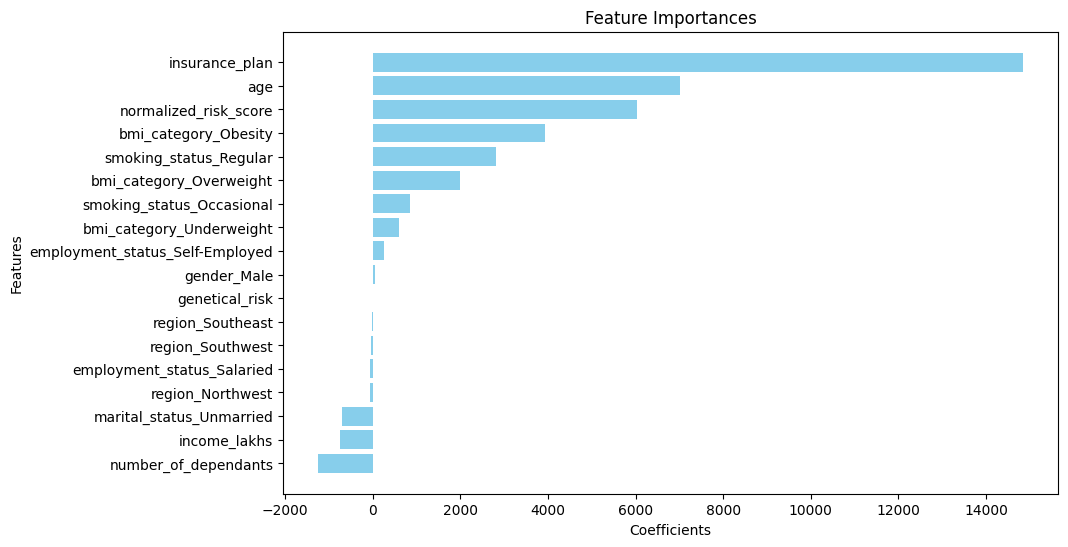

In [65]:

plt.figure(figsize=(10, 6))
plt.barh(coef_df.index, coef_df['Coefficients'], color='skyblue')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.show()

In [66]:
model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train, y_train)

y_pred_rg = model_rg.predict(X_test)
mse_rg = mean_squared_error(y_test, y_pred_rg)
rmse_rg = np.sqrt(mse_rg)
r2_rg = r2_score(y_test, y_pred_rg)

print("Ridge Regression Mean Squared Error (MSE):", mse_rg)
print("Ridge Regression Root Mean Squared Error (RMSE):", rmse_rg)
print("Ridge Regression R-squared (R2):", r2_rg)
print("Ridge Regression Test model score:", model_rg.score(X_test, y_test))
print("Ridge Regression Train model score:", model_rg.score(X_train, y_train))

Ridge Regression Mean Squared Error (MSE): 2183773.4154461697
Ridge Regression Root Mean Squared Error (RMSE): 1477.7595932512736
Ridge Regression R-squared (R2): 0.954612316781273
Ridge Regression Test model score: 0.954612316781273
Ridge Regression Train model score: 0.9530813964457598


In [67]:
from xgboost import XGBRegressor
model_xg = XGBRegressor(random_state=42)
model_xg.fit(X_train, y_train)

y_pred_xg = model_xg.predict(X_test)
mse_xg = mean_squared_error(y_test, y_pred_xg)
rmse_xg = np.sqrt(mse_xg)
r2_xg = r2_score(y_test, y_pred_xg)

print("XGBoost Regression Mean Squared Error (MSE):", mse_xg)
print("XGBoost Regression Root Mean Squared Error (RMSE):", rmse_xg)
print("XGBoost Regression R-squared (R2):", r2_xg)
print("XGBoost Regression Test model score:", model_xg.score(X_test, y_test))
print("XGBoost Regression Train model score:", model_xg.score(X_train, y_train))

XGBoost Regression Mean Squared Error (MSE): 95870.859375
XGBoost Regression Root Mean Squared Error (RMSE): 309.6301977763151
XGBoost Regression R-squared (R2): 0.9980074167251587
XGBoost Regression Test model score: 0.9980074167251587
XGBoost Regression Train model score: 0.9986407160758972


In [68]:
X_train.columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'insurance_plan',
       'genetical_risk', 'normalized_risk_score', 'gender_Male',
       'region_Northwest', 'region_Southeast', 'region_Southwest',
       'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [69]:
# Compatibility patch for sklearn 1.6 + older xgboost wrappers
from sklearn.base import RegressorMixin
from sklearn.utils._tags import Tags, TargetTags, RegressorTags

def _patched_sklearn_tags(self):
    return Tags(
        estimator_type='regressor',
        target_tags=TargetTags(required=True),
        regressor_tags=RegressorTags(),
    )

RegressorMixin.__sklearn_tags__ = _patched_sklearn_tags

model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
}
random_search = RandomizedSearchCV(
    estimator=model_xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.1}
0.9978681206703186


In [70]:
best_model = random_search.best_estimator_

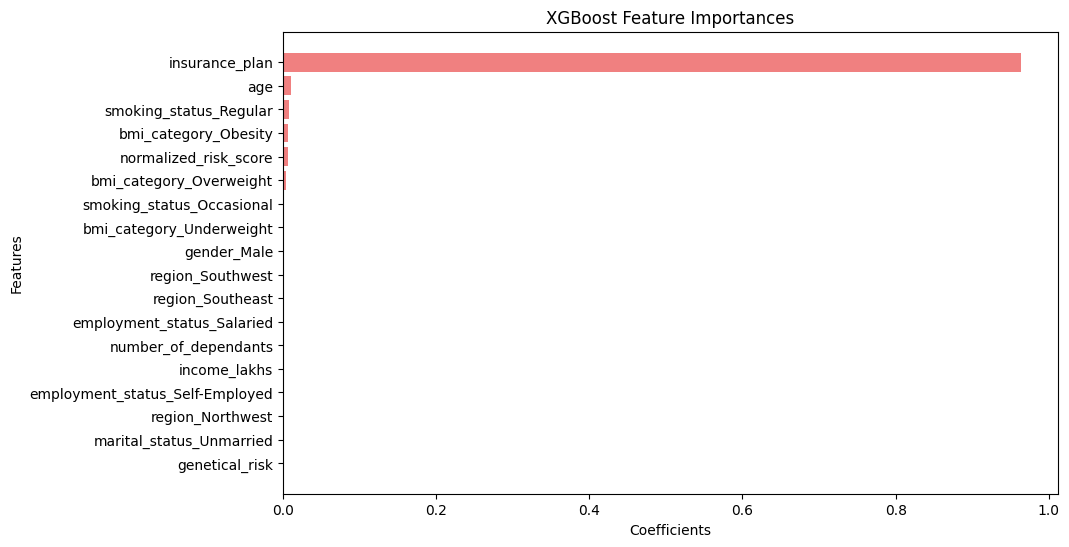

In [71]:
frature_importances = best_model.feature_importances_
coef_df_xgb = pd.DataFrame(frature_importances, index=X_reduced.columns, columns=['Coefficients'])
coef_df_xgb.sort_values(by='Coefficients', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(coef_df_xgb.index, coef_df_xgb['Coefficients'], color='lightcoral')
plt.xlabel("Coefficients")
plt.ylabel("Features")
plt.title("XGBoost Feature Importances")
plt.show()

### Error Analysis

In [72]:
y_pred_xgb = best_model.predict(X_test)

residuals = y_test - y_pred_xgb
residuals_pct = residuals*100 / y_test

residuals_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_xgb,
    'Residuals': residuals,
    'Residuals (%)': residuals_pct
})
residuals_df.head(10)

,Actual,Predicted,Residuals,Residuals (%)
5495,30838,31059.115234,-221.115234,-0.717022
582,26306,26084.128906,221.871094,0.843424
281,17983,17603.304688,379.695312,2.111413
15443,19345,19000.898438,344.101562,1.778762
24281,33317,33442.445312,-125.445312,-0.376520
13879,17888,17603.304688,284.695312,1.591544
23869,13338,13477.091797,-139.091797,-1.042823
9985,22635,22538.775391,96.224609,0.425114
1989,18057,18601.740234,-544.740234,-3.016781
29096,9614,9621.401367,-7.401367,-0.076985


<Axes: xlabel='Residuals (%)', ylabel='Count'>

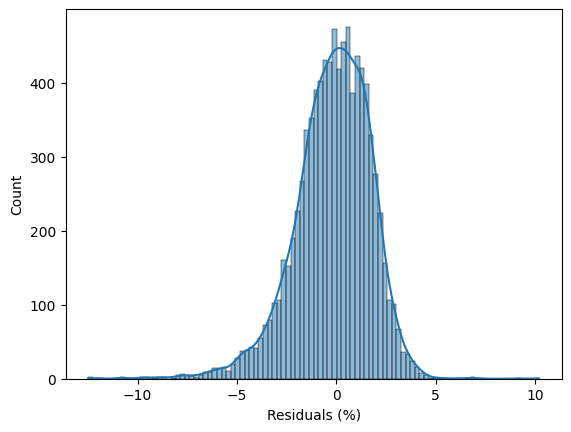

In [73]:
sns.histplot(residuals_df['Residuals (%)'], kde=True)

In [74]:
extreme_error_threshold = 10
extreme_results_df = residuals_df[np.abs(residuals_df['Residuals (%)']) > extreme_error_threshold]
extreme_results_df.shape

(8, 4)

In [75]:
extreme_error_percentage = extreme_results_df.shape[0]*100 / residuals_df.shape[0]
extreme_error_percentage

0.08941544651838605

In [76]:
residuals_df[np.abs(residuals_df['Residuals (%)']) > 50].sort_values(by='Residuals (%)', ascending=False).head(10)

,Actual,Predicted,Residuals,Residuals (%)


In [77]:
X_test.index

Index([ 5495,   582,   281, 15443, 24281, 13879, 23869,  9985,  1989, 29096,
       ...
        9378, 21318, 11748, 12471, 27270, 12305,  2117, 23521, 29683, 11077],
      dtype='int64', length=8947)

In [78]:
extreme_results_df.index

Index([8506, 6137, 8216, 8270, 15413, 17811, 21910, 16310], dtype='int64')

In [79]:
extreme_errors_df = X_test.loc[extreme_results_df.index]
extreme_errors_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
8506,0.391304,0.6,0.060606,0.0,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0
6137,0.369565,0.2,0.040404,0.0,0.0,0.0,1,0,0,1,1,0,0,0,0,0,0,0
8216,0.152174,0.4,0.010101,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0
8270,0.282609,0.0,0.000000,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,1,0
15413,0.000000,0.0,0.020202,0.0,0.0,0.0,1,1,0,0,1,0,0,0,0,0,0,0


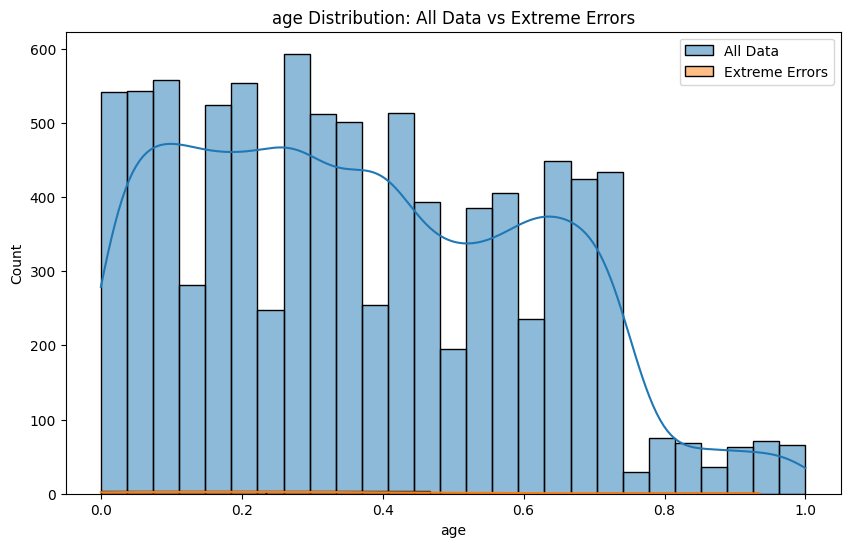

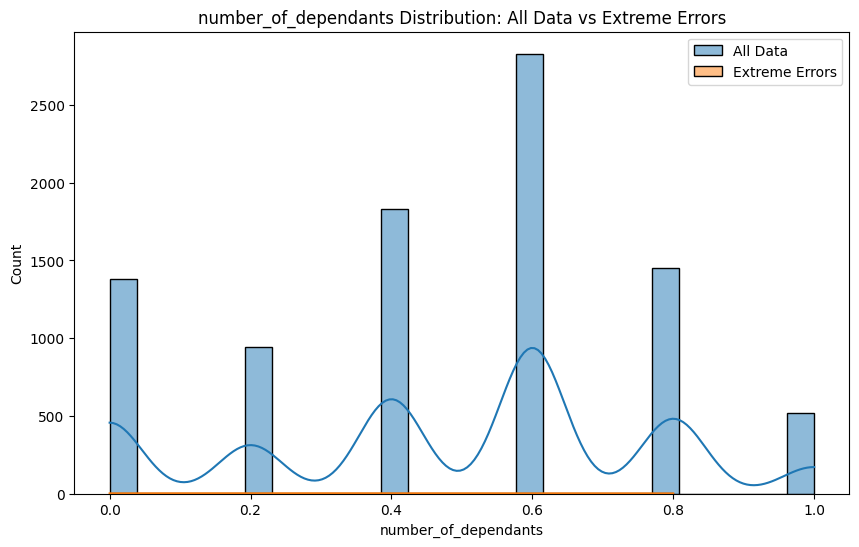

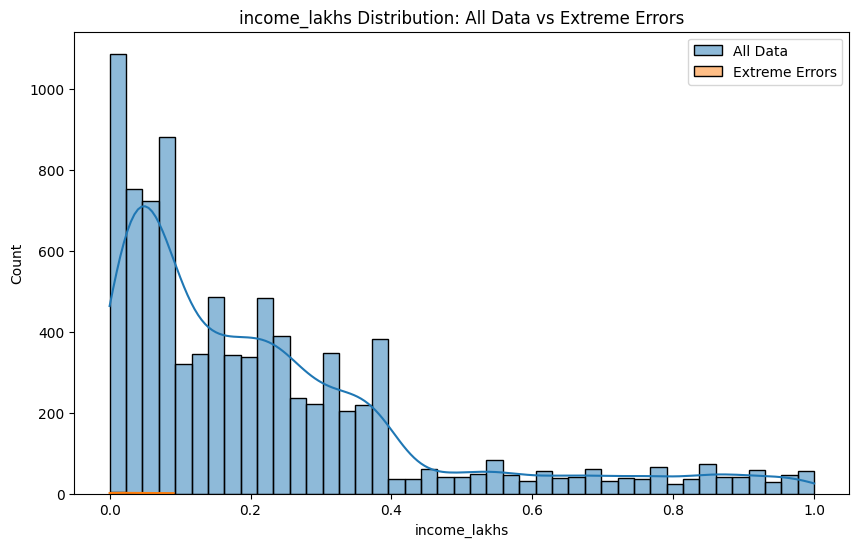

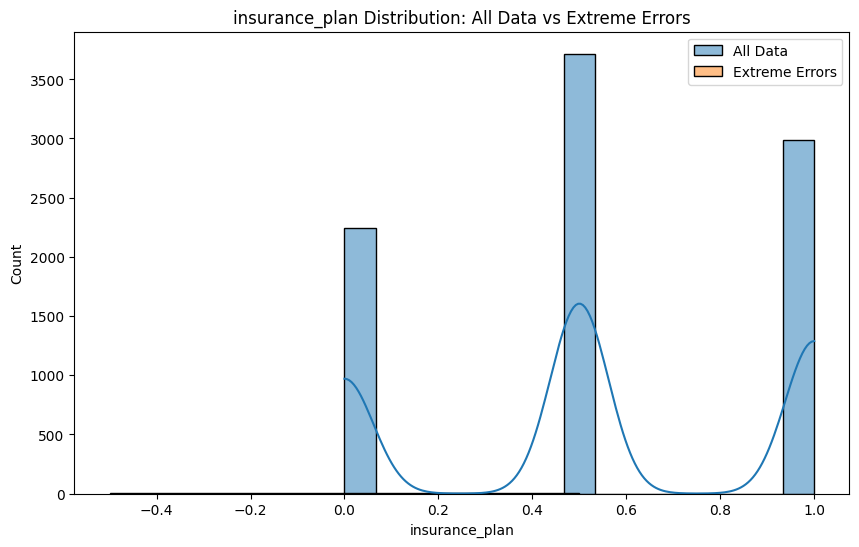

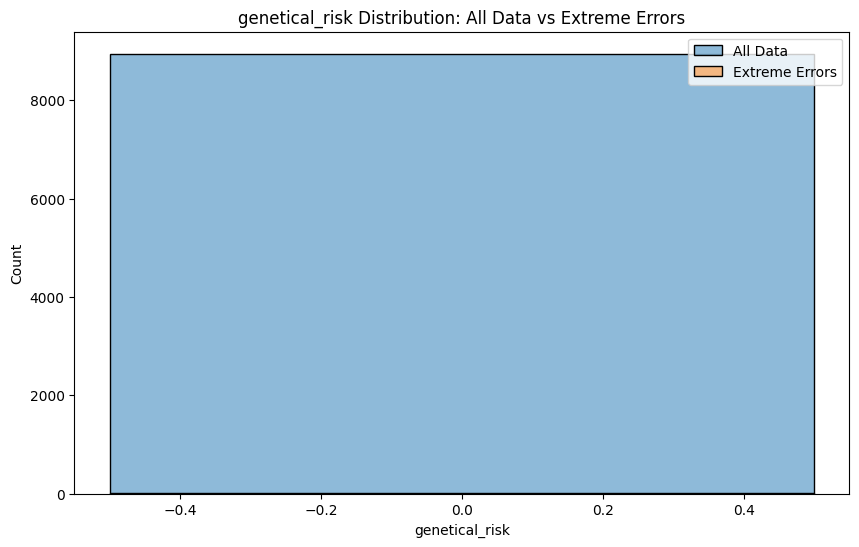

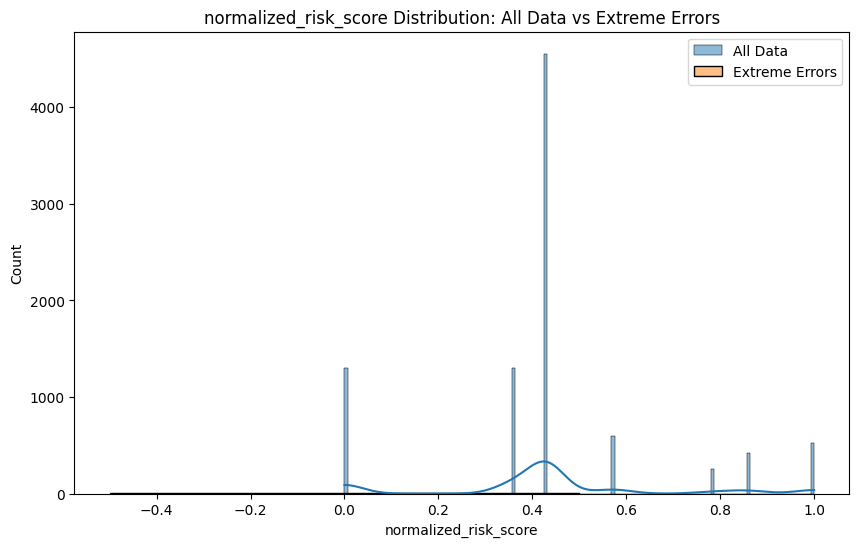

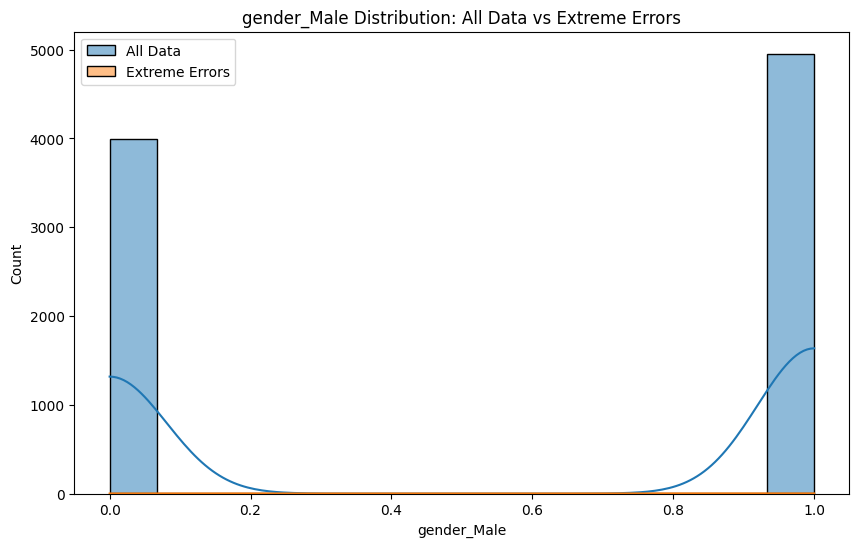

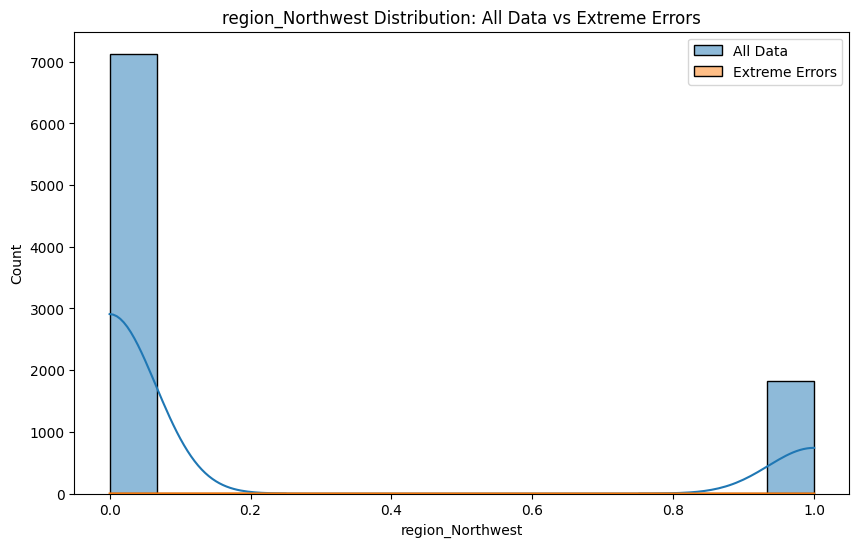

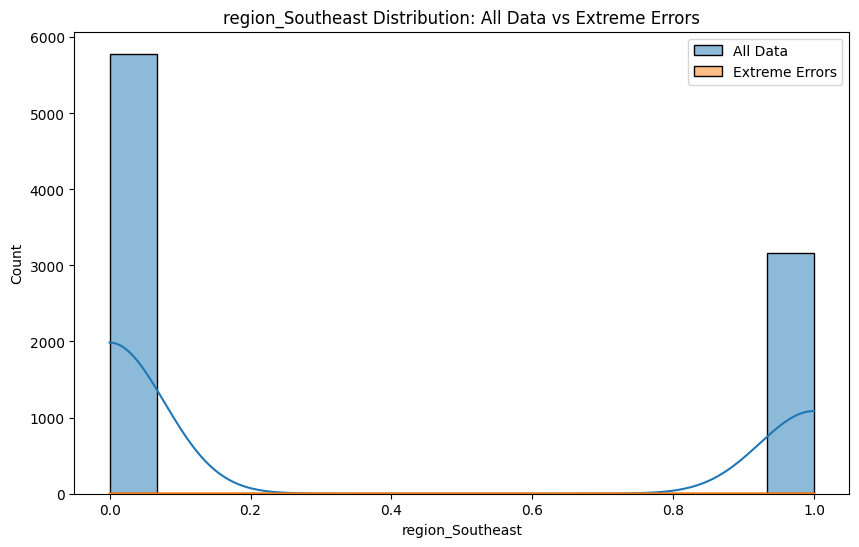

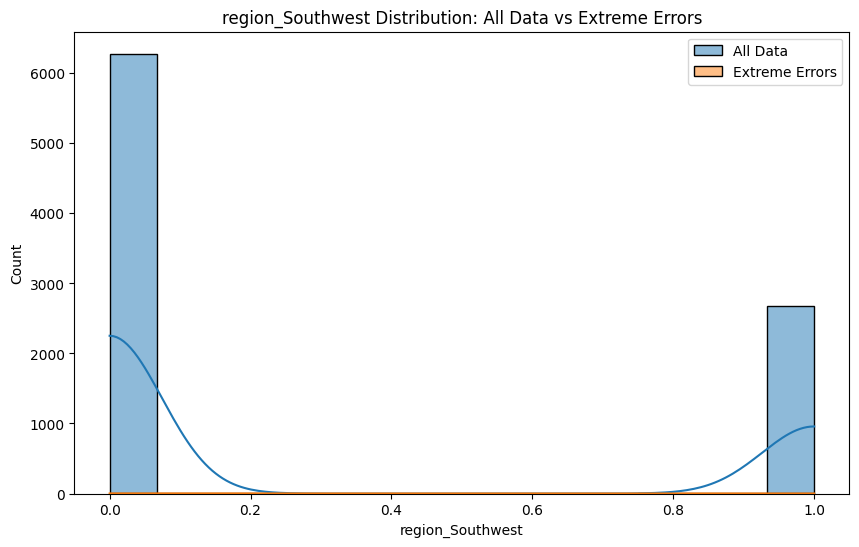

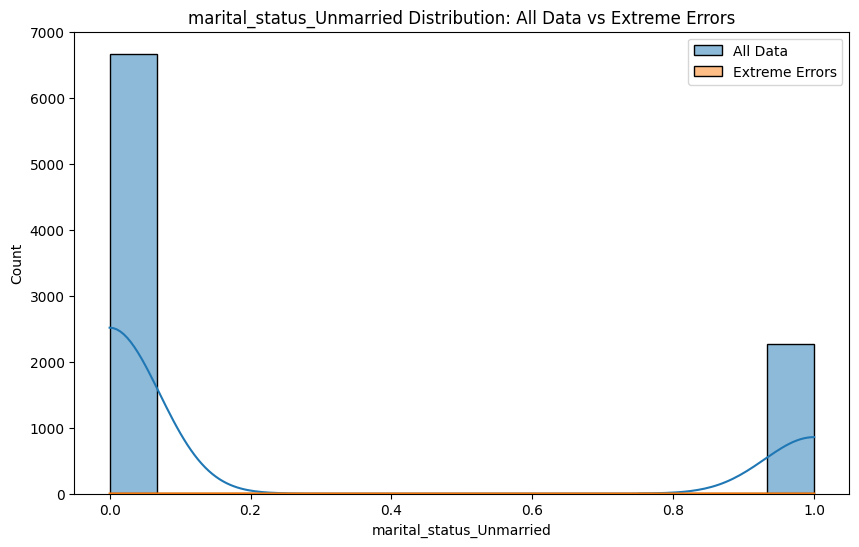

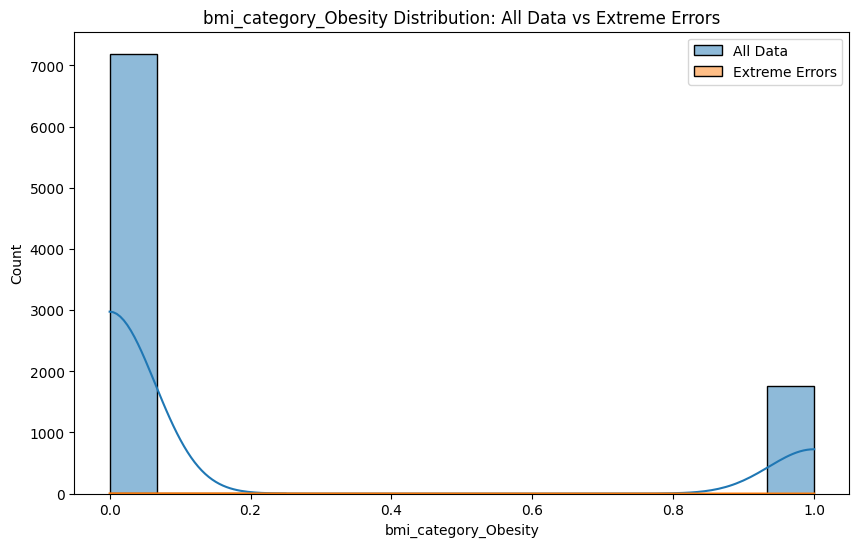

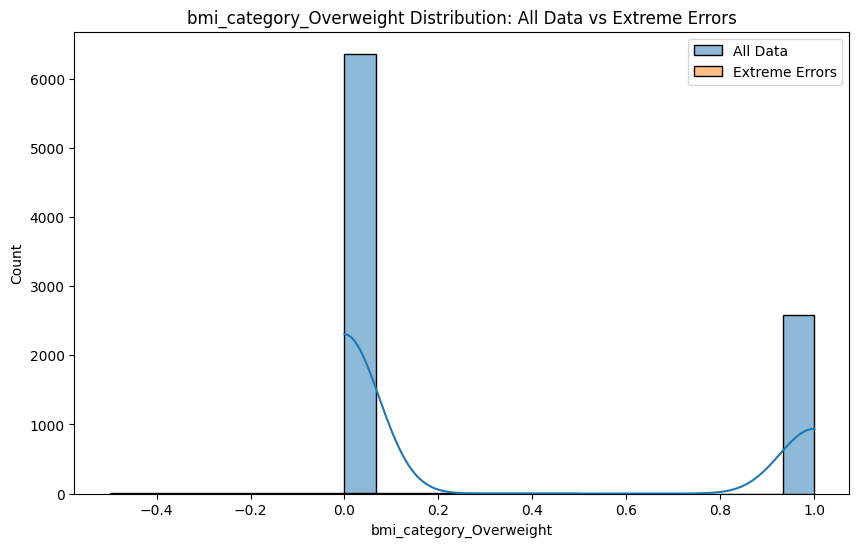

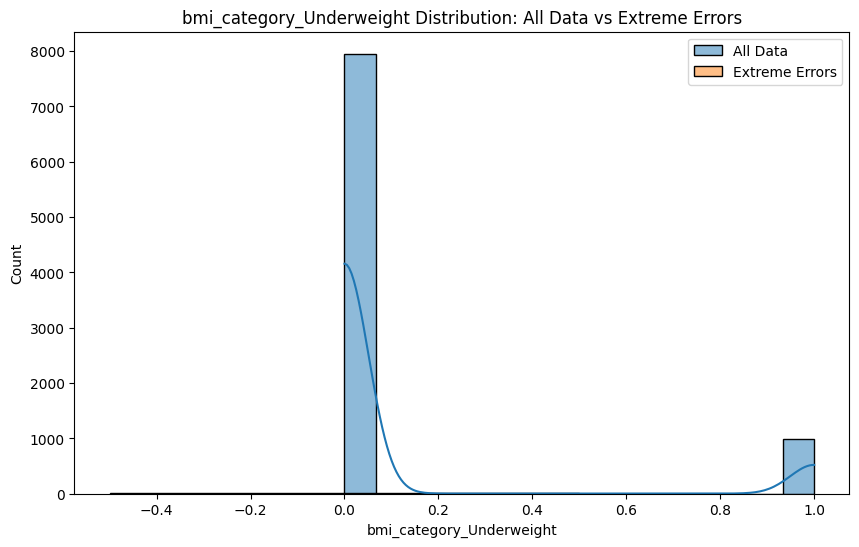

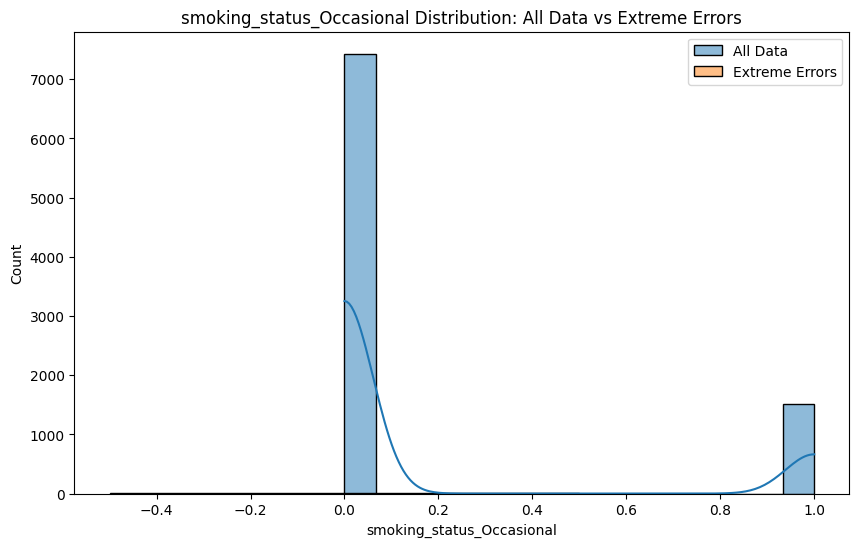

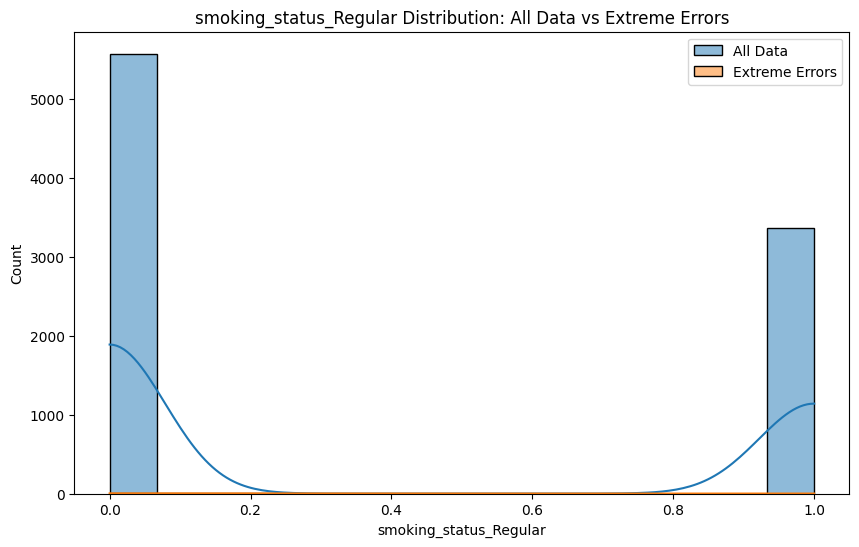

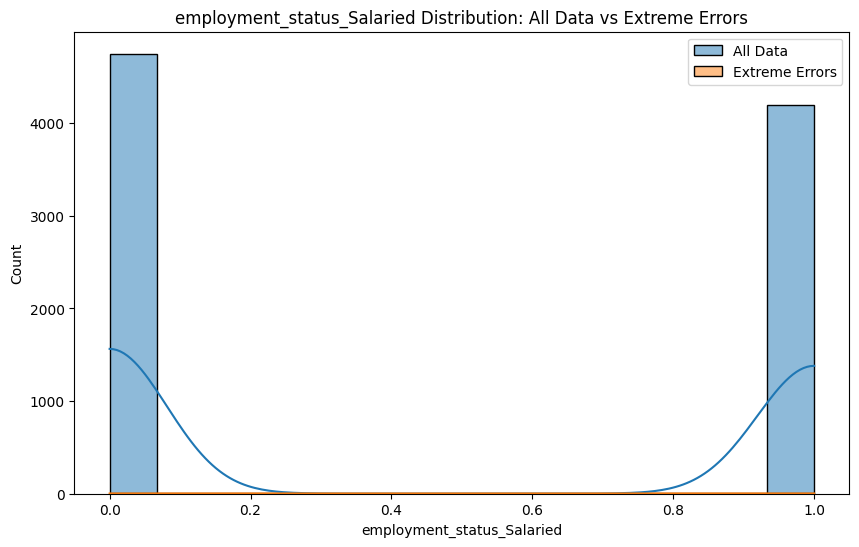

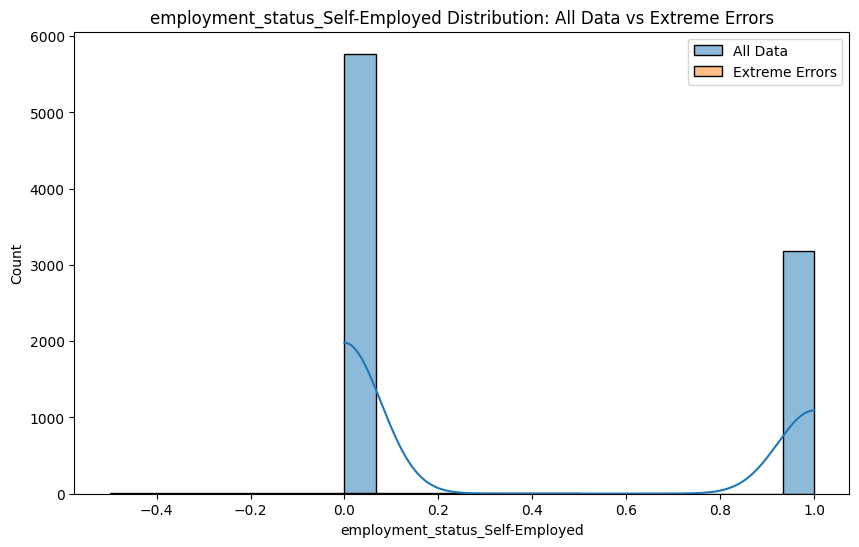

In [80]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_test[feature], label='All Data', kde=True)
    sns.histplot(extreme_errors_df[feature], label='Extreme Errors', kde=True)
    plt.legend()
    plt.title(f'{feature} Distribution: All Data vs Extreme Errors')
    plt.show()

In [81]:
scaled_cols_in_reduced = ['age', 'number_of_dependants', 'income_lakhs', 'insurance_plan', 'genetical_risk']
fitted_scaled_cols = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan', 'genetical_risk']

In [82]:
# No synthetic income_level column is needed; we inverse only the scaled columns present in X_reduced.

In [83]:
scaler

MinMaxScaler()

<Axes: xlabel='age', ylabel='Count'>

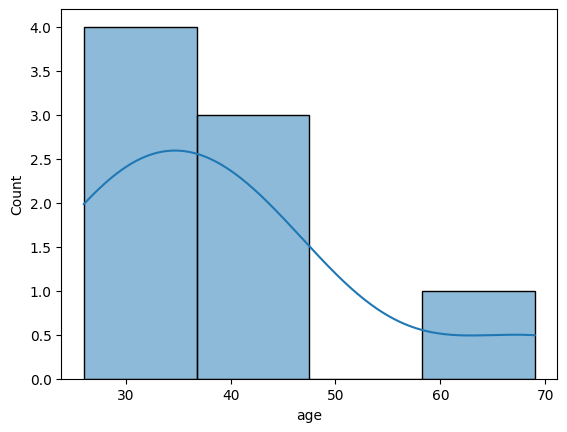

In [84]:
df_reversed = extreme_errors_df.copy()

# Map reduced scaled columns back using the original scaler's parameters.
idx = [fitted_scaled_cols.index(col) for col in scaled_cols_in_reduced]
scaled_vals = df_reversed[scaled_cols_in_reduced].to_numpy()
original_vals = (scaled_vals - scaler.min_[idx]) / scaler.scale_[idx]

df_reversed[scaled_cols_in_reduced] = original_vals

df_reversed

sns.histplot(df_reversed['age'], kde=True)

In [85]:
df_reversed['age'].quantile(0.97)

np.float64(63.75)

### Export Model for rest of the population 

In [86]:
from joblib import dump, load
dump(best_model, 'artifact/model_rest.joblib')                  



['artifact/model_rest.joblib']

In [87]:
columns_to_scale

['age',
 'number_of_dependants',
 'income_level',
 'income_lakhs',
 'insurance_plan',
 'genetical_risk']

In [ ]:
scaler_with_cols ={
    'scaler': scaler,
    'cols_to_scale': columns_to_scale
}

dump(scaler_with_cols, 'artifact/scaler_with_cols_rest.joblib')

['artifact/scaler_with_cols_rest.joblib']